# Creating a Filter, Edge Detection

### Import resources and display image

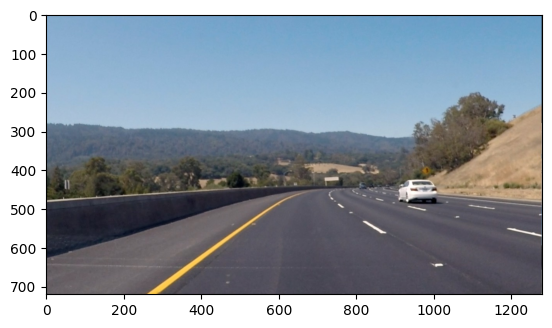

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import cv2
import numpy as np

%matplotlib inline

# Read in the image
image = mpimg.imread('images/curved_lane.jpg')

plt.imshow(image)

### Convert the image to grayscale

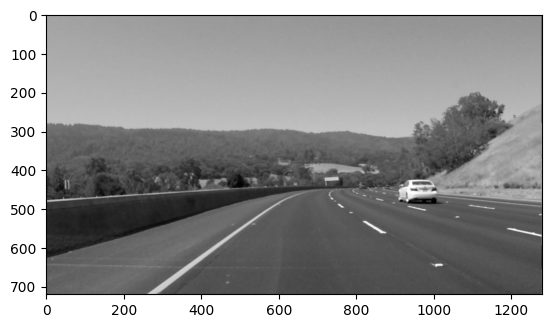

In [2]:
# Convert to grayscale for filtering
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')

### TODO: Create a custom kernel

Below, you've been given one common type of edge detection filter: a Sobel operator.

The Sobel filter is very commonly used in edge detection and in finding patterns in intensity in an image. Applying a Sobel filter to an image is a way of **taking (an approximation) of the derivative of the image** in the x or y direction, separately. The operators look as follows.

<img src="images/sobel_ops.png" width=200 height=200>

**It's up to you to create a Sobel x operator and apply it to the given image.**

For a challenge, see if you can put the image through a series of filters: first one that blurs the image (takes an average of pixels), and then one that detects the edges.

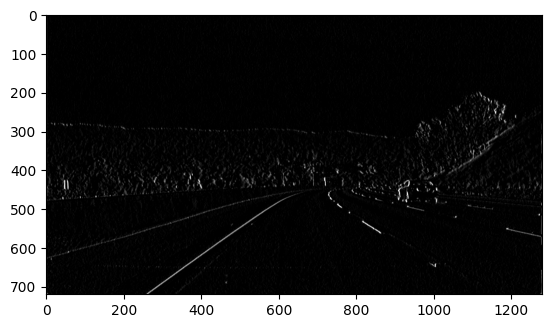

In [3]:
# Create a custom kernel

# 3x3 array for edge detection
sobel_y = np.array([[ -1, -2, -1],
                   [ 0, 0, 0],
                   [ 1, 2, 1]])

## TODO: Create and apply a Sobel x operator
sobel_x = np.array([[-1,0,1],
                   [-2,0,2],
                   [-1,0,1]])


# Filter the image using filter2D, which has inputs: (grayscale image, bit-depth, kernel)
filtered_image = cv2.filter2D(gray, -1, sobel_y)
filtered_image = cv2.filter2D(gray, -1, sobel_x)

plt.imshow(filtered_image, cmap='gray')

### Test out other filters!

You're encouraged to create other kinds of filters and apply them to see what happens! As an **optional exercise**, try the following:
* Create a filter with decimal value weights.
* Create a 5x5 filter
* Apply your filters to the other images in the `images` directory.



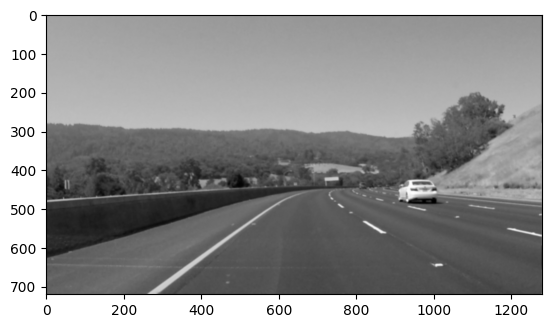

In [5]:
## Create and apply a 5x5 custom kernel
kernel_5x5 = np.array([
    [1, 4, 6, 4, 1],
    [4,16,24,16,4],
    [6,24,36,24,6],
    [4,16,24,16,4],
    [1,4,6,4,1]
], dtype=np.float32) / 256


# Filter the image using filter2D, which has inputs: (grayscale image, bit-depth, kernel)
filtered_image = cv2.filter2D(gray, -1, kernel_5x5)

plt.imshow(filtered_image, cmap='gray')

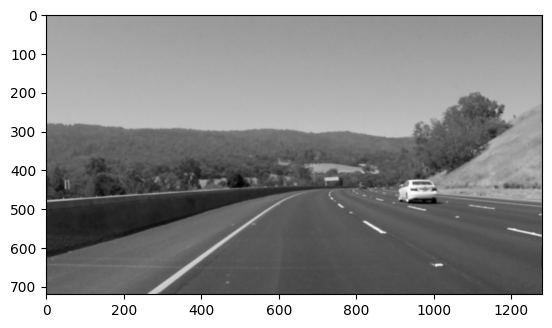

In [7]:
# Apply a 5x5 Gaussian-style blur with decimal weights
gaussian_5x5 = np.array([
    [1, 4, 7, 4, 1],
    [4,16,26,16,4],
    [7,26,41,26,7],
    [4,16,26,16,4],
    [1,4,7,4,1]
], dtype=np.float32)
gaussian_5x5 /= gaussian_5x5.sum()
blurred_image = cv2.filter2D(gray, -1, gaussian_5x5)
plt.imshow(blurred_image, cmap='gray')


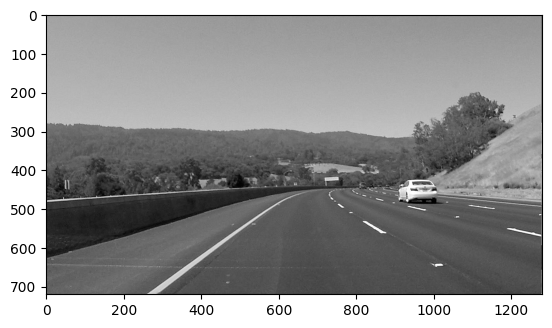

In [8]:
# Apply a sharpening filter to highlight edges
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)
sharpened_image = cv2.filter2D(gray, -1, sharpen_kernel)
plt.imshow(sharpened_image, cmap='gray')


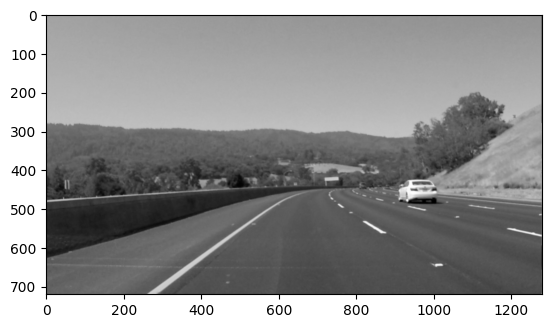

In [9]:
# Apply a filter with decimal weights
decimal_kernel = np.array([
    [ 0.05, 0.10, 0.05],
    [ 0.10, 0.40, 0.10],
    [ 0.05, 0.10, 0.05]
], dtype=np.float32)
decimal_image = cv2.filter2D(gray, -1, decimal_kernel)
plt.imshow(decimal_image, cmap='gray')
